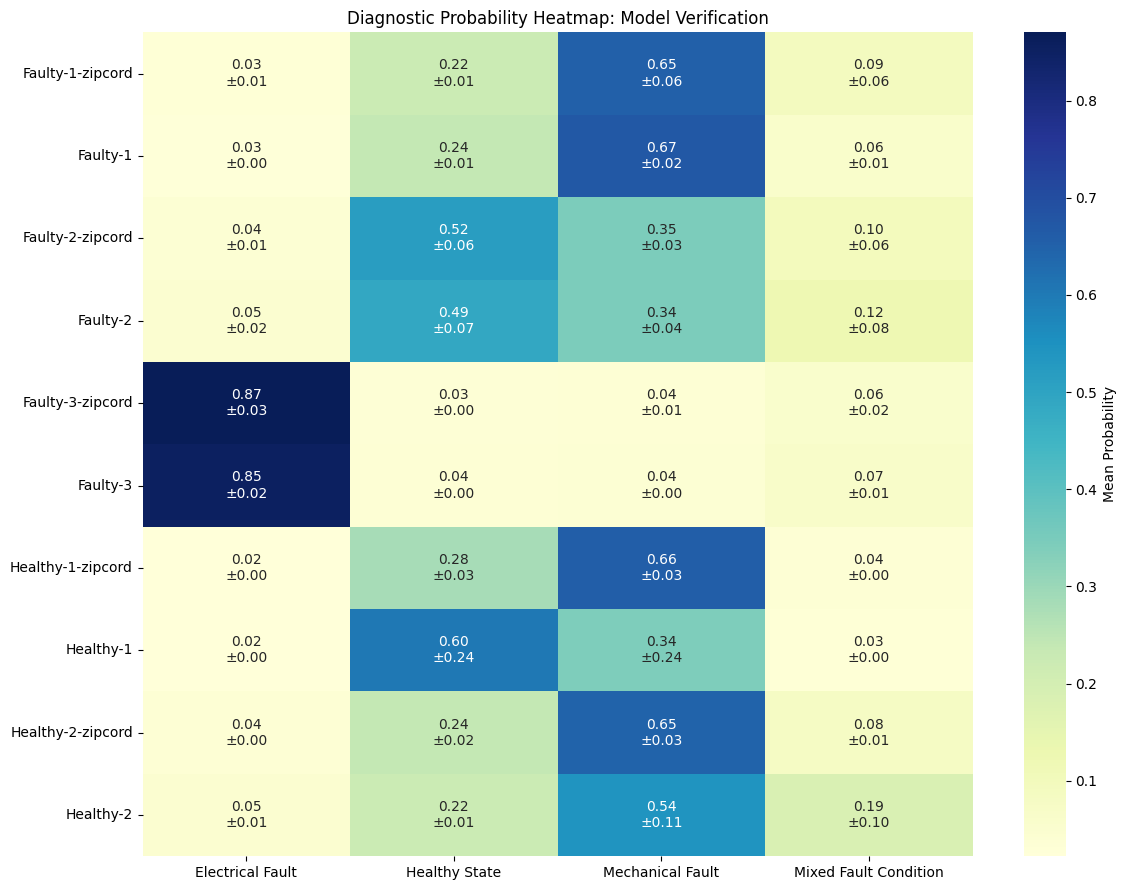

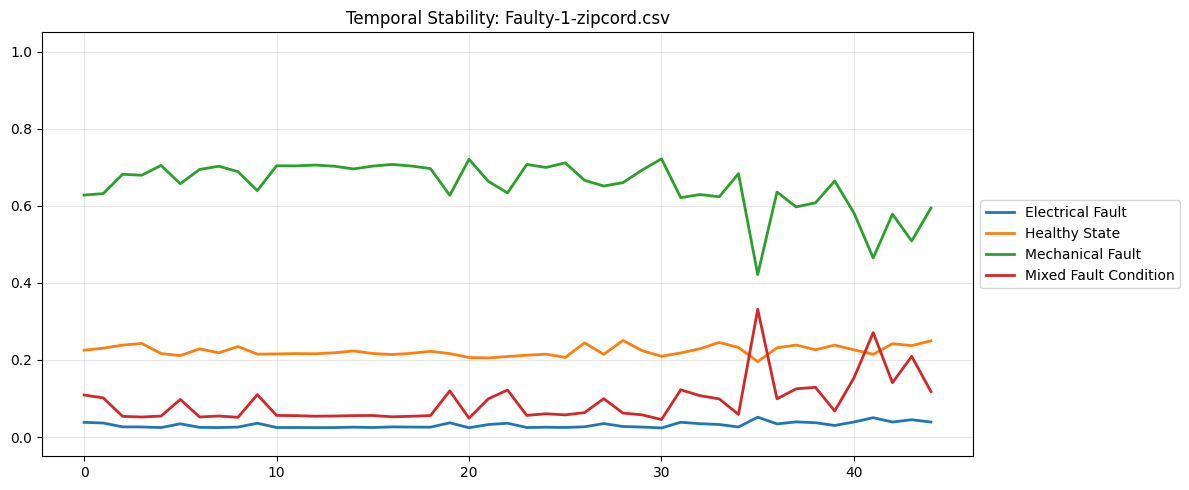

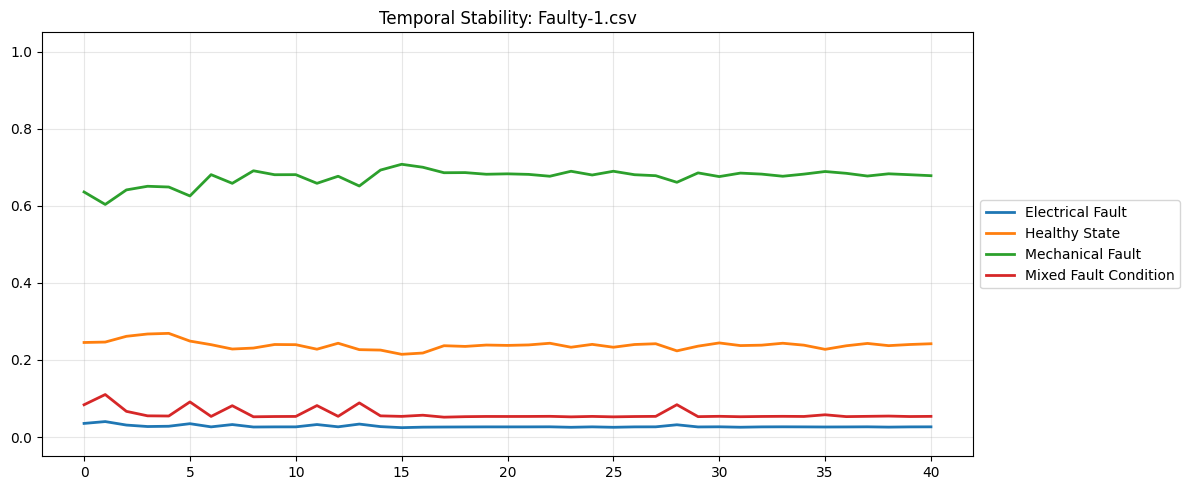

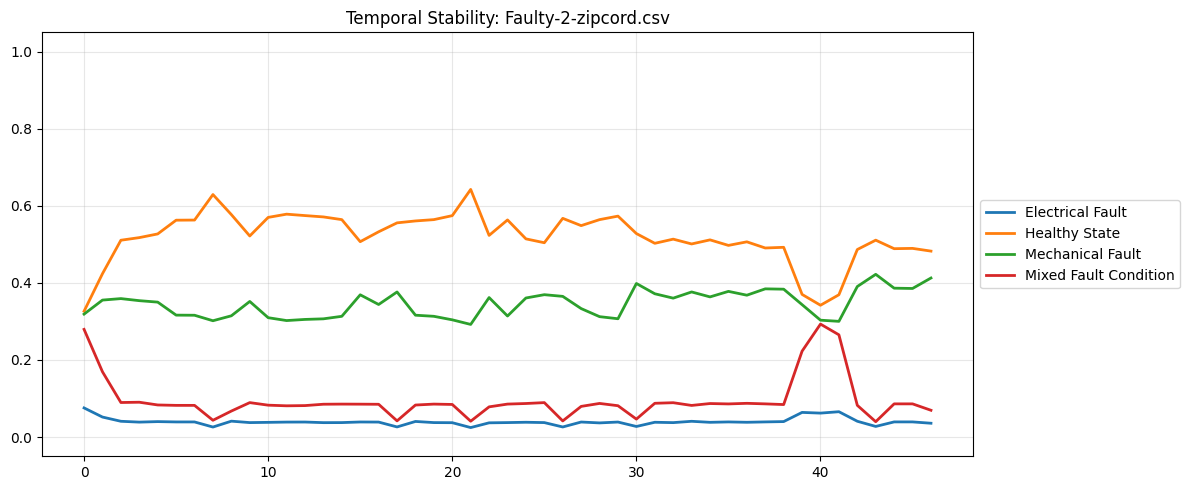

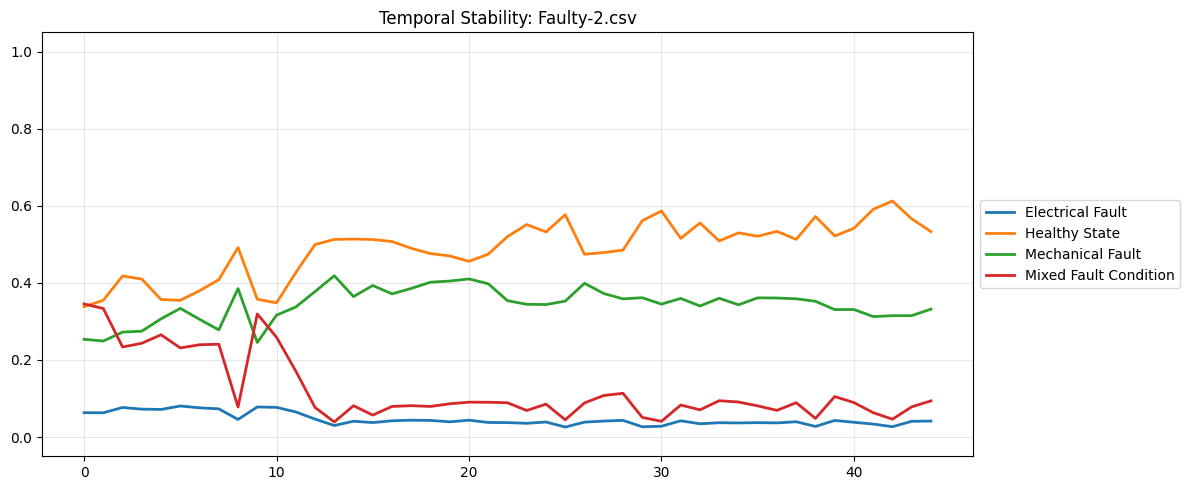

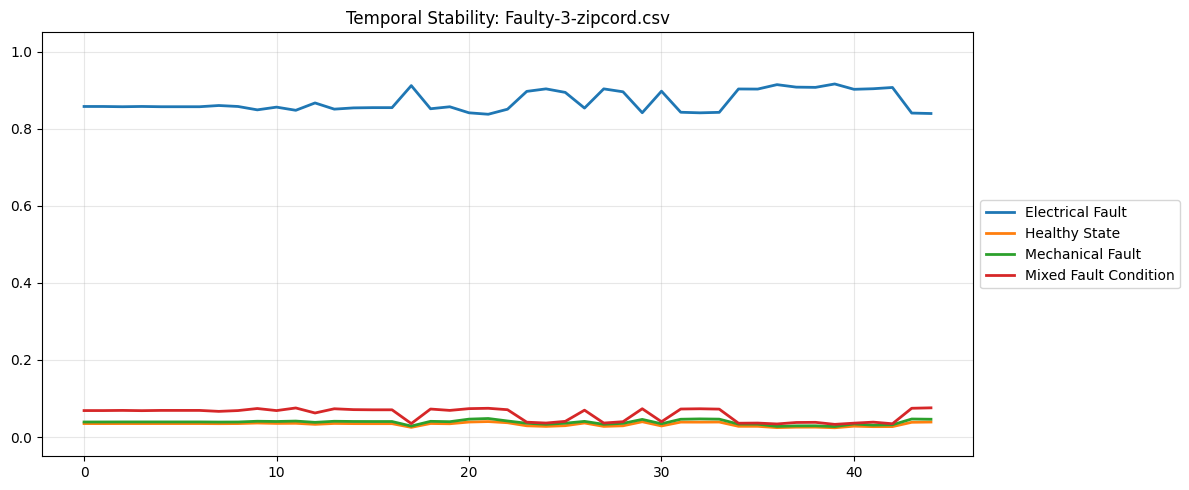

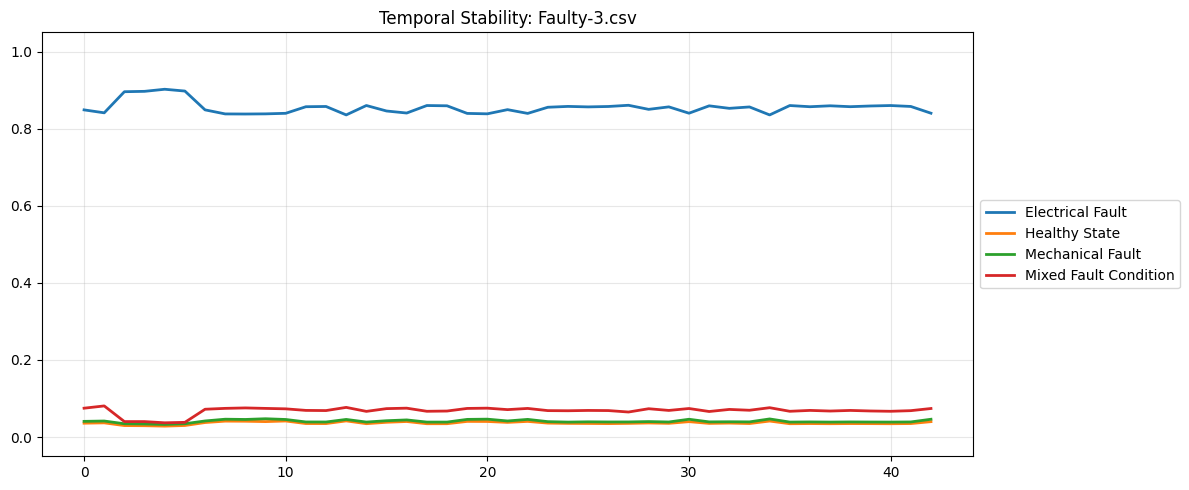

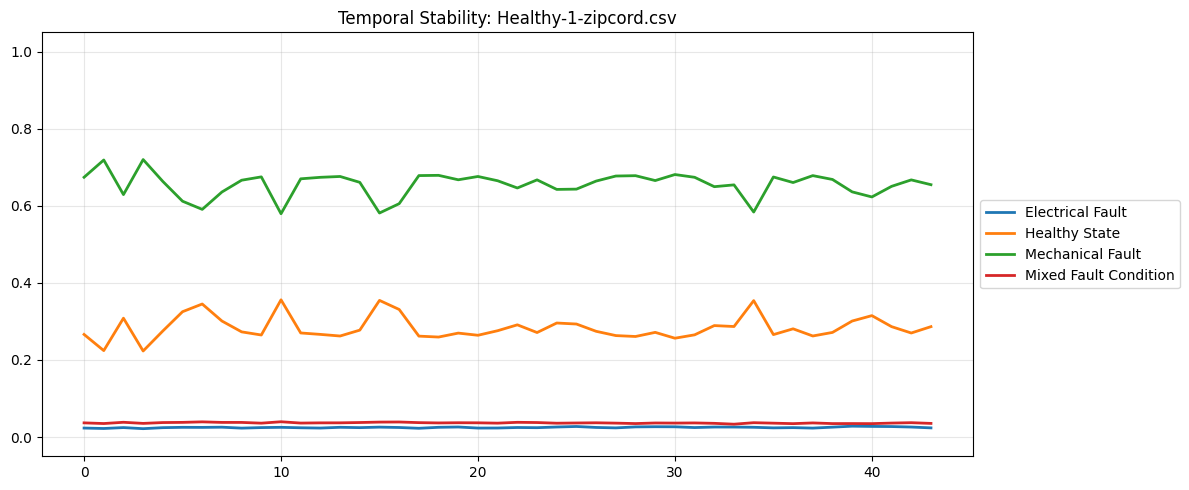

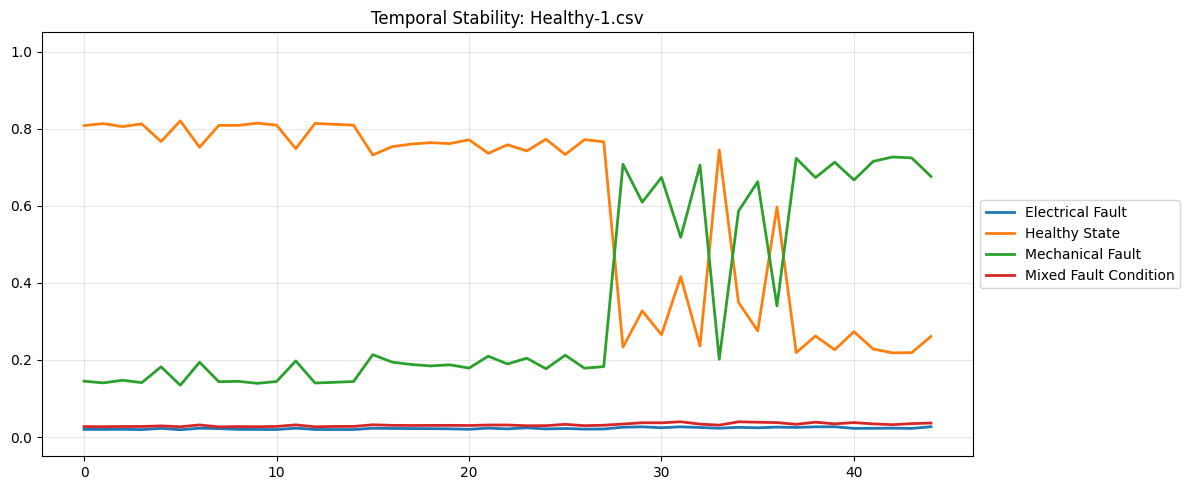

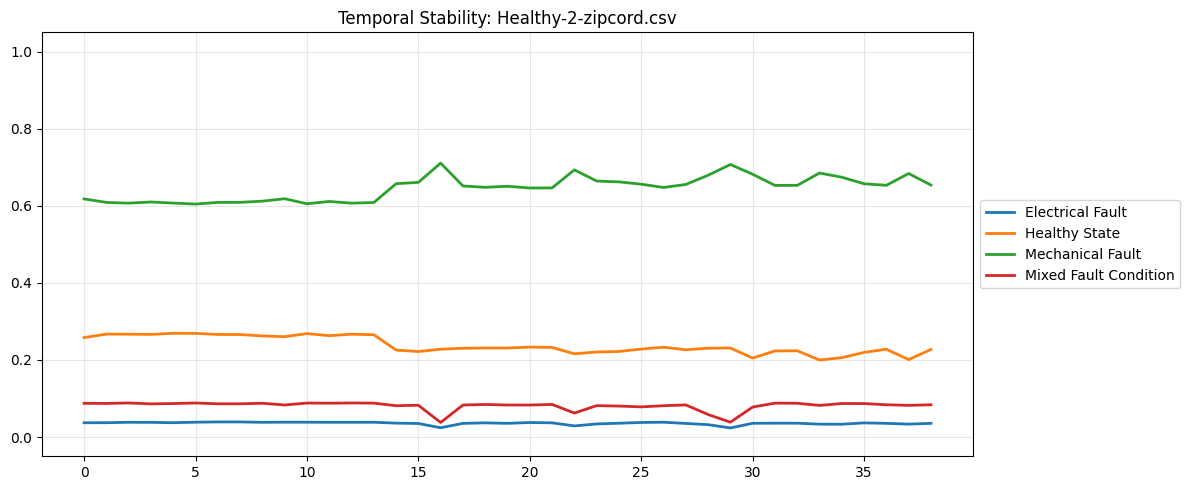

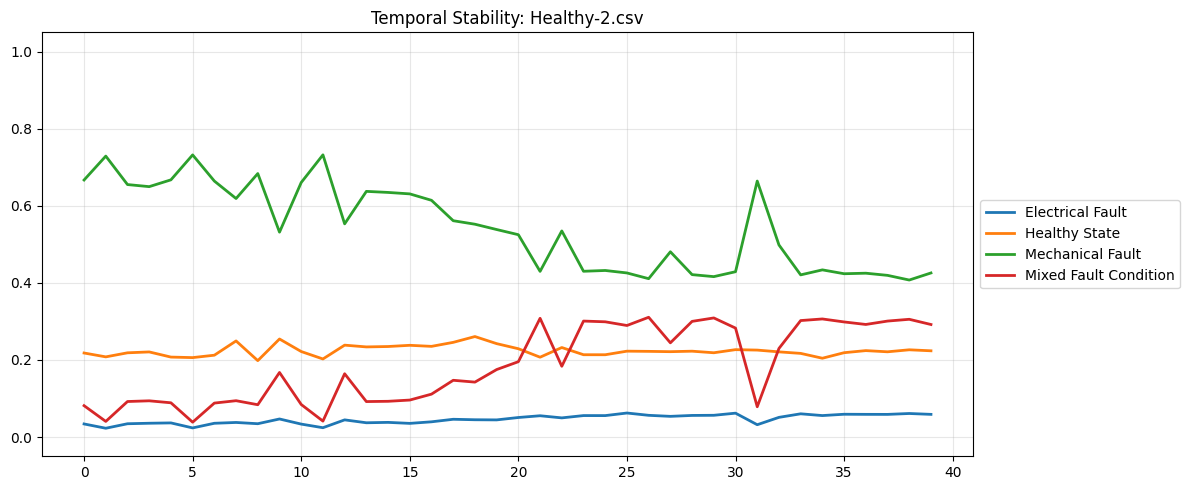

In [1]:
import pandas as pd
import numpy as np
import glob
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression

os.environ["LOKY_MAX_CPU_COUNT"] = "1"

def robust_map_classes(df):
    def mapper(name):
        name = str(name).strip().lower()
        if 'healthy' in name: return 'Healthy State'
        elif 'elec' in name and 'mech' in name: return 'Mixed Fault Condition'
        elif 'elec' in name: return 'Electrical Fault'
        elif 'mech' in name: return 'Mechanical Fault'
        return None
    df['Class'] = df['Class'].apply(mapper)
    return df.dropna(subset=['Class'])

def train_stacking_model():
    df = pd.read_csv("motors.csv", sep=None, engine='python')
    df = df.drop(columns=[c for c in df.columns if c.startswith("is_") or "Unnamed" in c], errors="ignore")
    df = robust_map_classes(df)
    
    X, y = df.drop(columns=["Class"]), df["Class"]
    
    estimators = [
        ('rf_std', RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=1)),
        ('rf_shallow', RandomForestClassifier(n_estimators=200, max_depth=5, random_state=42, n_jobs=1)),
        ('rf_dense', RandomForestClassifier(n_estimators=500, min_samples_split=2, random_state=42, n_jobs=1))
    ]
    
    model = StackingClassifier(estimators=estimators, final_estimator=LogisticRegression(max_iter=1000), cv=5, n_jobs=1)
    model.fit(X, y)
    return model, X.columns, model.classes_

model, feature_names, class_names = train_stacking_model()

new_files = sorted(glob.glob('Faulty-*.csv') + glob.glob('Healthy-*.csv'))
means, stds, file_labels = [], [], []

for file in new_files:
    df_new = pd.read_csv(file, sep=None, engine='python')
    if 'Experiment ID' in df_new.columns:
        df_new = df_new[df_new['Experiment ID'] != 0]
    
    if not df_new.empty:
        probs = model.predict_proba(df_new[feature_names])
        means.append(np.mean(probs, axis=0))
        stds.append(np.std(probs, axis=0))
        file_labels.append(file.replace(".csv", "").replace("_", " "))

df_means = pd.DataFrame(means, index=file_labels, columns=class_names)
annot_matrix = [[f"{m:.2f}\n±{s:.2f}" for m, s in zip(m_row, s_row)] 
                for m_row, s_row in zip(df_means.values, stds)]

plt.figure(figsize=(12, 9))
sns.heatmap(df_means, annot=annot_matrix, fmt="", cmap="YlGnBu", cbar_kws={'label': 'Mean Probability'})
plt.title("Diagnostic Probability Heatmap: Model Verification")
plt.tight_layout()
plt.show()

for file in new_files:
    df_step = pd.read_csv(file, sep=None, engine='python')
    if 'Experiment ID' in df_step.columns:
        df_step = df_step[df_step['Experiment ID'] != 0]
    
    if not df_step.empty:
        probs = model.predict_proba(df_step[feature_names])
        plt.figure(figsize=(12, 5))
        for i, label in enumerate(class_names):
            plt.plot(probs[:, i], label=label, linewidth=2)
        plt.title(f"Temporal Stability: {file}")
        plt.ylim(-0.05, 1.05)
        plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()